# Check Simulation Results

Visualize simulation results. Equivalent to `check_results.R`.

Produces four panel plots for psi03:
- Empirical variance
- Empirical mean (bias check)
- Mean squared error
- Coverage (95% CI using empirical SD)

Run after `run_simulation.py` has produced `simulation_results.pkl`.

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [26]:
RESULTS_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "simulation_results.pkl")
OUTPUT_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "simulation_results_plots.pdf")
TRUE_PSI03 = 1.0  # true value used in check_results.R

In [27]:
def load_results(path=RESULTS_PATH):
    if path.endswith(".pkl"):
        return pd.read_pickle(path)
    return pd.read_csv(path)

In [28]:
def rename_methods(df):
    method_map = {
        "Three-step": "Three-step estimator",
        "Robins' estimator": "Simple g-estimator",
        "GMM estimator": "GMM estimator",
        "eff": "Semiparametric efficient estimator",
    }
    df = df.copy()
    df["method"] = df["method"].map(method_map).fillna(df["method"])
    return df

In [29]:
TRUE_PSI03 = 1
TRUE_PSI13 = 1
TRUE_PSI23 = 1
def summarize(df, true_psi03=TRUE_PSI03, true_psi13=TRUE_PSI13, true_psi23=TRUE_PSI23):
    """Compute per-(p_I, ph, method) summary statistics for psi03, psi13, psi23."""
    def coverage(x):
        sd = np.std(x, ddof=1)
        return np.mean((x - 1.96 * sd < true_psi03) & (x + 1.96 * sd > true_psi03))

    summary = (
        df.groupby(["p_I", "ph", "method"])
        .agg(
            mean_psi03=("est_psi03", "mean"),
            bias_psi03 = ("est_psi03", lambda x: np.mean(x) - true_psi03),
            var_psi03=("est_psi03", "var"),
            mse_psi03=("est_psi03", lambda x: np.mean((x - true_psi03) ** 2)),
            coverage_psi03=("est_psi03", coverage),
            mean_psi13=("est_psi13", "mean"),
            bias_psi13 = ("est_psi13", lambda x: np.mean(x) - true_psi13),
            var_psi13=("est_psi13", "var"),
            mean_psi23=("est_psi23", "mean"),
            bias_psi23 = ("est_psi23", lambda x: np.mean(x) - true_psi23),
            var_psi23=("est_psi23", "var"),
        )
        .reset_index()
    )
    return summary

In [30]:
COLORS = ["#3B4992", "#EE0000", "#008B45", "#631879"]
METHODS = [
    "Three-step estimator",
    "Simple g-estimator",
    "GMM estimator",
]

In [31]:
def plot_variance(summary, output_path=None):
    """Plot empirical variance of psi03, psi13, psi23 by ph, with one column per p_I value."""
    p_I_values = sorted(summary["p_I"].unique())
    n_cols = len(p_I_values)
    psis = [
        ("var_psi03", r"Empirical variance of $\psi_{03}$"),
        ("var_psi13", r"Empirical variance of $\psi_{13}$"),
        ("var_psi23", r"Empirical variance of $\psi_{23}$"),
    ]
    color_map = {m: COLORS[i] for i, m in enumerate(METHODS)}
    ph_values = sorted(summary["ph"].unique())
    x = np.arange(len(ph_values))
    n_methods = len(METHODS)
    bar_width = 0.8 / n_methods

    fig, axes = plt.subplots(
        3, n_cols, figsize=(4 * n_cols, 10), sharey="row", constrained_layout=True
    )
    if n_cols == 1:
        axes = axes.reshape(3, 1)

    for col_i, p_I in enumerate(p_I_values):
        sub = summary[summary["p_I"] == p_I]
        for row_i, (metric, ylabel) in enumerate(psis):
            ax = axes[row_i, col_i]
            for m_i, method in enumerate(METHODS):
                msub = sub[sub["method"] == method].sort_values("ph")
                if msub.empty:
                    continue
                offsets = x + (m_i - (n_methods - 1) / 2) * bar_width
                ax.bar(
                    offsets, msub[metric].values,
                    width=bar_width, label=method,
                    color=color_map[method], alpha=0.85,
                )
            if col_i == 0:
                ax.set_ylabel(ylabel, fontsize=9)
            if row_i == 0:
                ax.set_title(f"Eligibility proportion\n$p_I = {p_I}$", fontsize=9)
            ax.set_xticks(x)
            ax.set_xticklabels([str(ph) for ph in ph_values], fontsize=8)
            ax.set_xlabel(r"Proportion $A_1 = A_0$ (ph)", fontsize=8)
            ax.tick_params(labelsize=8)
            ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", ncol=len(METHODS),
        fontsize=9, bbox_to_anchor=(0.5, 1.03), frameon=False,
    )
    if output_path:
        var_path = output_path.replace(".pdf", "_variance.pdf")
        fig.savefig(var_path, dpi=300, bbox_inches="tight")
        print(f"Saved variance plot to {var_path}")
    plt.show()

In [32]:
df = load_results()
df = rename_methods(df)
df = df[df["method"].isin(METHODS)]
summary = summarize(df)
print(summary.to_string(index=False))

 p_I  ph               method  mean_psi03  bias_psi03    var_psi03    mse_psi03  coverage_psi03  mean_psi13  bias_psi13    var_psi13  mean_psi23  bias_psi23    var_psi23
0.25 0.4        GMM estimator    0.999845   -0.000155 4.948608e-06 4.923156e-06            0.95    1.000101    0.000101 7.400837e-06    1.000164    0.000164 6.109795e-06
0.25 0.4   Simple g-estimator    0.999766   -0.000234 5.182908e-06 5.186067e-06            0.94    1.000035    0.000035 8.207929e-06    1.000046    0.000046 8.160761e-06
0.25 0.4 Three-step estimator    0.999828   -0.000172 6.904209e-06 6.864810e-06            0.94    0.999856   -0.000144 8.950315e-06    1.000046    0.000046 8.160761e-06
0.25 0.6        GMM estimator    0.999979   -0.000021 3.236494e-07 3.208704e-07            0.94    1.000048    0.000048 4.649690e-06    1.000107    0.000107 2.431898e-06
0.25 0.6   Simple g-estimator    0.999975   -0.000025 5.818272e-07 5.766238e-07            0.95    1.000077    0.000077 5.238316e-06    1.000103    0.

In [33]:
var_cols = ["p_I", "ph", "method", "var_psi03", "var_psi13", "var_psi23"]
print(summary[var_cols].to_string(index=False))

 p_I  ph               method    var_psi03    var_psi13    var_psi23
0.25 0.4        GMM estimator 4.948608e-06 7.400837e-06 6.109795e-06
0.25 0.4   Simple g-estimator 5.182908e-06 8.207929e-06 8.160761e-06
0.25 0.4 Three-step estimator 6.904209e-06 8.950315e-06 8.160761e-06
0.25 0.6        GMM estimator 3.236494e-07 4.649690e-06 2.431898e-06
0.25 0.6   Simple g-estimator 5.818272e-07 5.238316e-06 4.502080e-06
0.25 0.6 Three-step estimator 3.187816e-07 7.001437e-06 4.502080e-06
0.25 0.8        GMM estimator 6.679599e-08 4.789737e-06 2.004794e-06
0.25 0.8   Simple g-estimator 1.151039e-07 5.777998e-06 5.245322e-06
0.25 0.8 Three-step estimator 6.905273e-08 9.514383e-06 5.245322e-06
0.50 0.4        GMM estimator 3.952898e-06 3.175893e-06 3.346500e-06
0.50 0.4   Simple g-estimator 4.271209e-06 3.283983e-06 4.260830e-06
0.50 0.4 Three-step estimator 6.909918e-06 4.501675e-06 4.260830e-06
0.50 0.6        GMM estimator 3.185339e-07 2.045170e-06 1.141682e-06
0.50 0.6   Simple g-estimator 6.63

Saved variance plot to /Users/fuyuguo/PhD_thesis/Thesis_1_SNTTEM/Codes/three_time_continuous/psi1_python/simulation_results_plots_variance.pdf


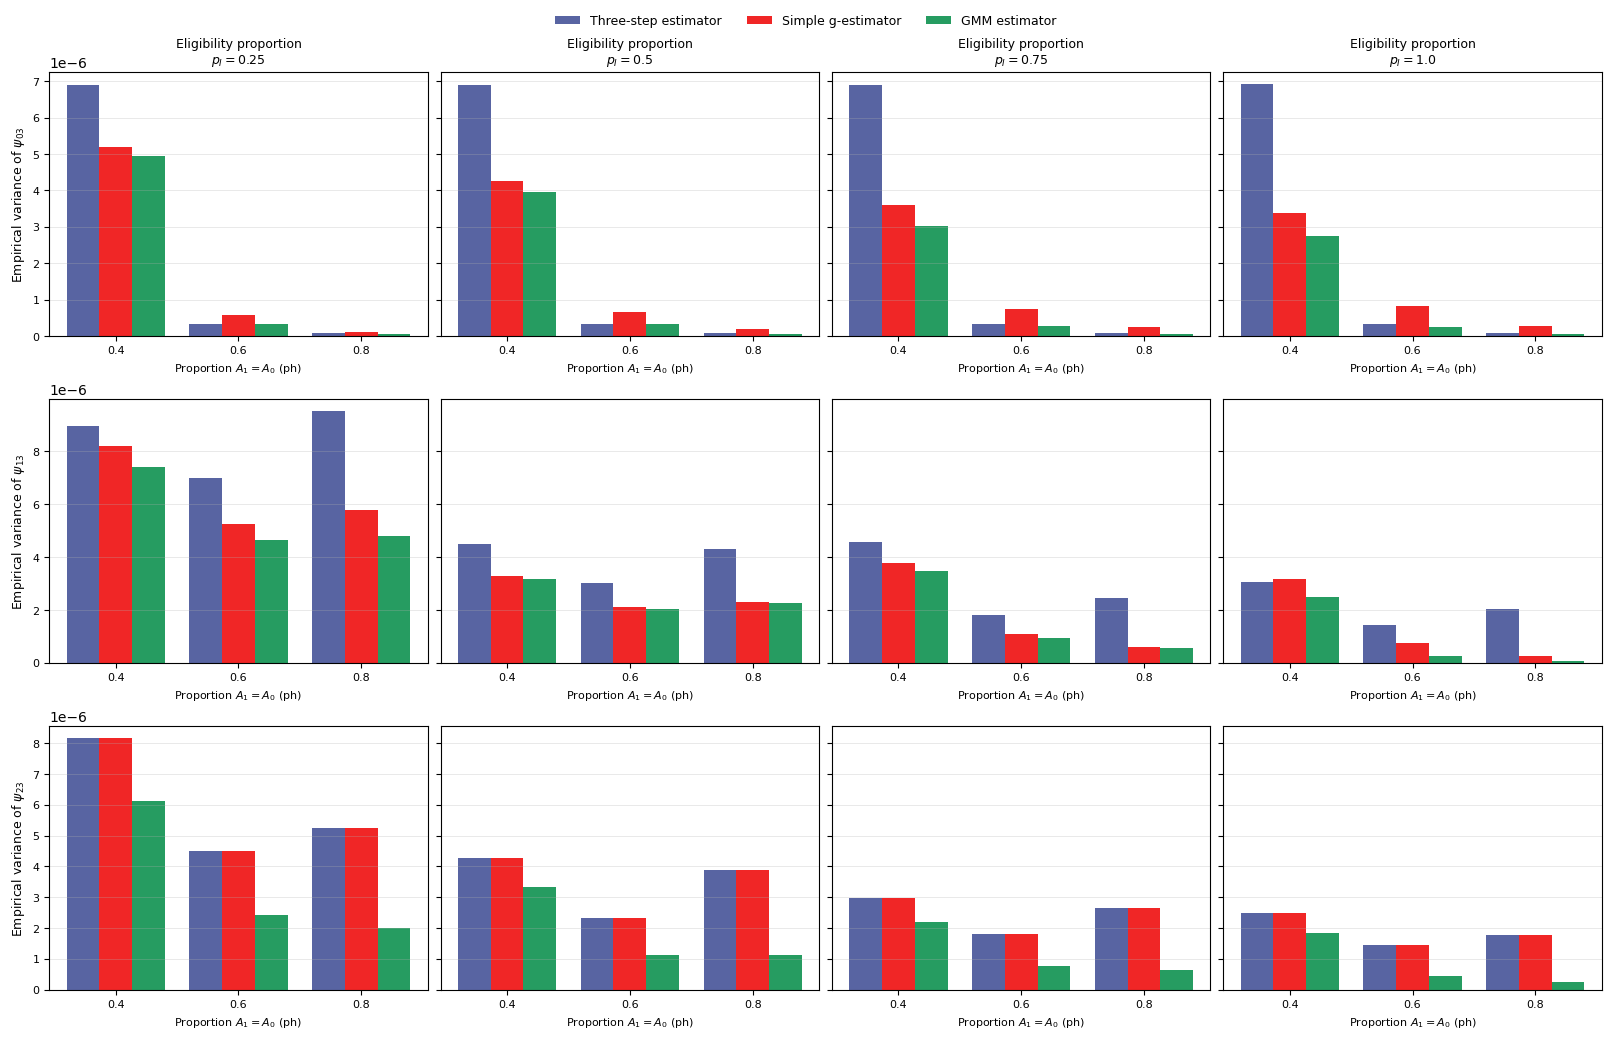

In [34]:
plot_variance(summary, output_path=OUTPUT_PATH)

In [35]:
def plot_bias(summary, output_path=None):
    """Plot empirical variance of psi03, psi13, psi23 by ph, with one column per p_I value."""
    p_I_values = sorted(summary["p_I"].unique())
    n_cols = len(p_I_values)
    psis = [
        ("bias_psi03", r"Empirical bias of $\psi_{03}$"),
        ("bias_psi13", r"Empirical bias of $\psi_{13}$"),
        ("bias_psi23", r"Empirical bias of $\psi_{23}$"),
    ]
    color_map = {m: COLORS[i] for i, m in enumerate(METHODS)}
    ph_values = sorted(summary["ph"].unique())
    x = np.arange(len(ph_values))
    n_methods = len(METHODS)
    bar_width = 0.8 / n_methods

    fig, axes = plt.subplots(
        3, n_cols, figsize=(4 * n_cols, 10), sharey="row", constrained_layout=True
    )
    if n_cols == 1:
        axes = axes.reshape(3, 1)

    for col_i, p_I in enumerate(p_I_values):
        sub = summary[summary["p_I"] == p_I]
        for row_i, (metric, ylabel) in enumerate(psis):
            ax = axes[row_i, col_i]
            for m_i, method in enumerate(METHODS):
                msub = sub[sub["method"] == method].sort_values("ph")
                if msub.empty:
                    continue
                offsets = x + (m_i - (n_methods - 1) / 2) * bar_width
                ax.bar(
                    offsets, msub[metric].values,
                    width=bar_width, label=method,
                    color=color_map[method], alpha=0.85,
                )
            if col_i == 0:
                ax.set_ylabel(ylabel, fontsize=9)
            if row_i == 0:
                ax.set_title(f"Eligibility proportion\n$p_I = {p_I}$", fontsize=9)
            ax.set_xticks(x)
            ax.set_xticklabels([str(ph) for ph in ph_values], fontsize=8)
            ax.set_xlabel(r"Proportion $A_1 = A_0$ (ph)", fontsize=8)
            ax.tick_params(labelsize=8)
            ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", ncol=len(METHODS),
        fontsize=9, bbox_to_anchor=(0.5, 1.03), frameon=False,
    )
    if output_path:
        var_path = output_path.replace(".pdf", "_bias.pdf")
        fig.savefig(var_path, dpi=300, bbox_inches="tight")
        print(f"Saved bias plot to {var_path}")
    plt.show()

Saved bias plot to /Users/fuyuguo/PhD_thesis/Thesis_1_SNTTEM/Codes/three_time_continuous/psi1_python/simulation_results_plots_bias.pdf


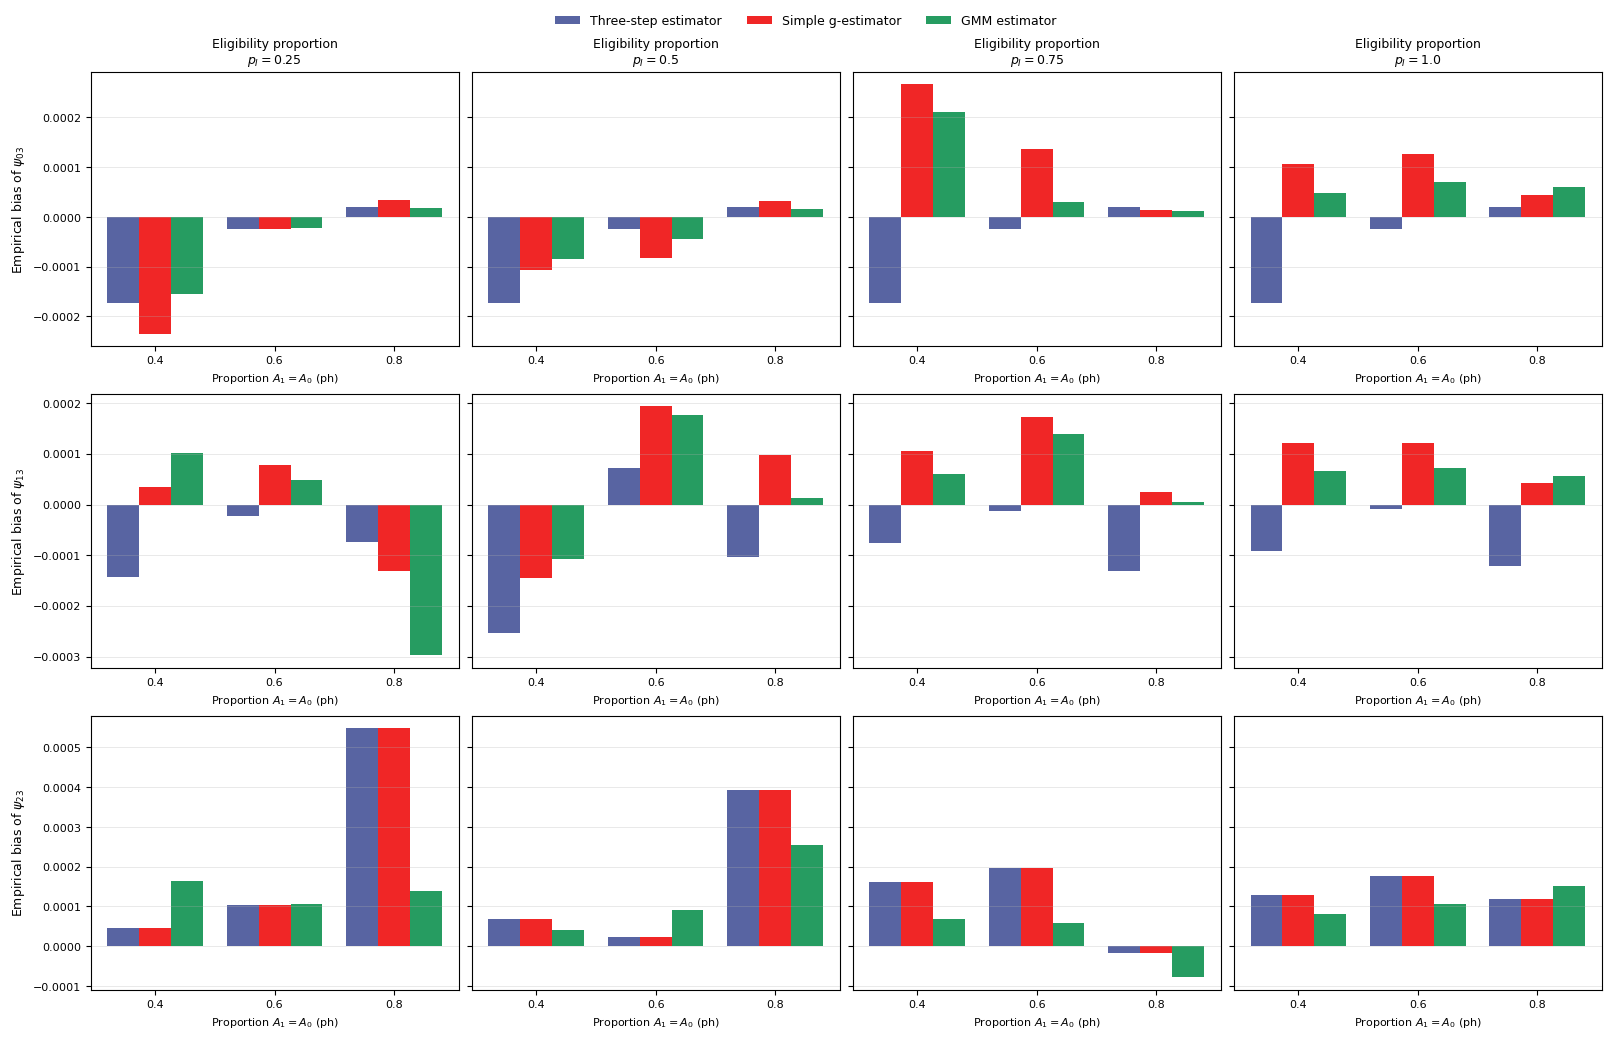

In [36]:
plot_bias(summary, output_path=OUTPUT_PATH)